# Student Performance Data Analysis

## Maincrafts Technology - Data Science/Analysis with Python Internship

### Task 1: Student Performance Dataset

### Project Objective

The objective of this project is to explore, clean, analyze, and visualize the Student Performance dataset using Python. The analysis focuses on understanding student academic performance and identifying relationships between study time, gender, and final grades.

### Analysis Questions

1. What is the average final grade (G3)?
2. How many students scored above 15?
3. Is study time correlated with student performance?
4. Which gender performs better on average?

### Tools and Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Load the Dataset

The Student Performance dataset is loaded using the Pandas library. The dataset contains information about students including demographic details, family background, study habits, and academic grades.

The `G3` column represents the final grade and is used as the main performance variable in this analysis.

In [2]:
df = pd.read_csv("student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Explore and Clean the Dataset

In this section, the dataset is explored to understand its structure, dimensions, data types, missing values, and duplicate records. Data cleaning is performed to ensure the dataset is suitable for further analysis.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 395
Number of columns: 33


### Observation

The dataset contains 395 student records and 33 columns. Each row represents a student, while the columns represent different demographic, social, academic, and performance-related attributes.

In [4]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


### Observation

The dataset contains various student-related attributes. The `studytime` column represents weekly study time, while `G1`, `G2`, and `G3` represent first-period, second-period, and final grades respectively. The `G3` column is the main final performance variable used in this analysis.

In [5]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

### Observation

The dataset contains both numerical and categorical variables. Numerical columns are represented using integer data types, while categorical variables such as school, sex, address, and family-related attributes are represented as object data types.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

### Observation

The dataset information provides an overview of all columns, their non-null counts, and data types. This helps identify potential missing values and understand the structure of the dataset before performing analysis.

In [7]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [8]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


### Observation

The dataset contains no missing values. Therefore, no missing value treatment such as deletion or imputation is required.

In [9]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [10]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (395, 33)


### Observation

The dataset was checked for duplicate records, and no duplicates were found. The `drop_duplicates()` function was applied as a precaution to ensure the dataset contains unique records.

In [11]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 3. Data Analysis

In this section, the cleaned Student Performance dataset is analyzed to answer the key analysis questions. The analysis focuses on final grades, high-performing students, the relationship between study time and academic performance, and gender-based performance comparison.

### 3.1 Average Final Grade (G3)

The `G3` column represents the final grade of each student. The mean of the `G3` column is calculated to determine the overall average final grade.

In [12]:
average_g3 = df["G3"].mean()

print("Average Final Grade (G3):", round(average_g3, 2))

Average Final Grade (G3): 10.42


### Observation

The average final grade (G3) of the students is approximately **10.42 out of 20**. This indicates that the overall academic performance of students is around the middle of the grading scale.

### 3.2 Students Scoring Above 15

Students with a final grade (`G3`) greater than 15 are identified as high-performing students. The number of such students is calculated using conditional filtering.

In [13]:
students_above_15 = df[df["G3"] > 15]

print("Number of Students Scoring Above 15:", len(students_above_15))

Number of Students Scoring Above 15: 40


### Observation

A total of **40 students scored above 15** in their final grade (G3). These students can be considered high-performing students based on their final academic results.

### 3.3 Correlation Between Study Time and Final Grade

Correlation analysis is performed to examine the relationship between weekly study time (`studytime`) and final academic performance (`G3`).

The correlation coefficient ranges from -1 to +1:

- A positive value indicates a positive relationship.
- A negative value indicates a negative relationship.
- A value close to 0 indicates a weak or no linear relationship.

In [14]:
studytime_correlation = df["studytime"].corr(df["G3"])

print("Correlation Between Study Time and G3:", round(studytime_correlation, 3))

Correlation Between Study Time and G3: 0.098


### Observation

The correlation coefficient between study time and final grade (G3) is approximately **0.098**. This indicates a **very weak positive correlation** between study time and final performance.

Therefore, study time alone does not show a strong linear relationship with students' final grades in this dataset. Other factors may also influence academic performance.

### 3.4 Gender-Based Average Performance

The average final grade (G3) is calculated for male and female students to compare academic performance based on gender.

In [15]:
gender_average = df.groupby("sex")["G3"].mean()

print("Average Final Grade by Gender:")
print(gender_average)

Average Final Grade by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


### Observation

Male students have an average final grade of approximately **10.91**, while female students have an average final grade of approximately **9.97**.

Therefore, male students performed slightly better on average than female students in this dataset. However, this result only describes the observed dataset and should not be interpreted as a general conclusion about gender and academic ability.

## 4. Data Visualization

Data visualization is used to visually explore patterns and relationships in the Student Performance dataset. The following visualizations present the distribution of final grades, the relationship between study time and final performance, and the average performance of male and female students.

### 4.1 Distribution of Final Grades

A histogram is used to visualize the distribution of students' final grades (`G3`). It helps identify how frequently different grade ranges occur in the dataset.

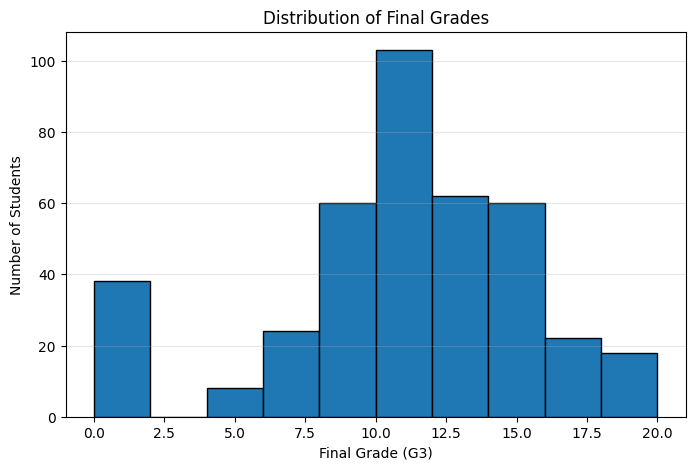

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["G3"], bins=10, edgecolor="black")

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Observation

The histogram shows the distribution of students' final grades. Most students scored within the middle grade range, while fewer students achieved very high grades. The distribution also shows a group of students with a final grade of zero, which may represent students who did not successfully complete the final assessment or received no final grade.

### 4.2 Study Time vs Final Grade

A scatter plot is used to visualize the relationship between weekly study time (`studytime`) and final grade (`G3`). Each point represents a student's study time and corresponding final grade.

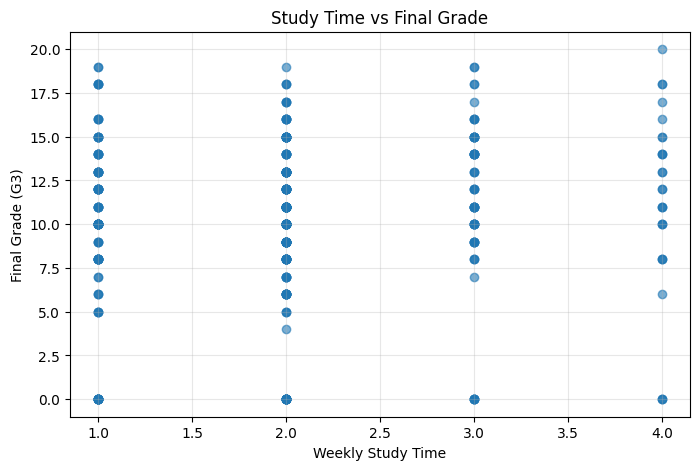

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(df["studytime"], df["G3"], alpha=0.6)

plt.title("Study Time vs Final Grade")
plt.xlabel("Weekly Study Time")
plt.ylabel("Final Grade (G3)")

plt.grid(alpha=0.3)
plt.show()

### Observation

The scatter plot shows that students with different study time levels have a wide range of final grades. There is no clear strong linear pattern between study time and final grade.

This visual observation supports the calculated correlation coefficient of approximately **0.098**, indicating a very weak positive relationship between study time and academic performance.

### 4.3 Average Final Grade by Gender

A bar chart is used to compare the average final grade (`G3`) of male and female students.

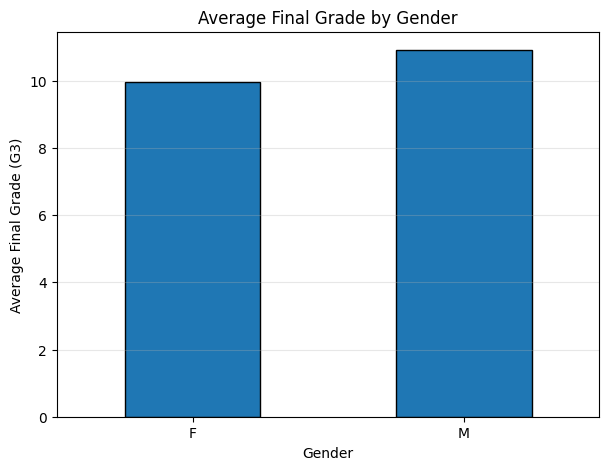

In [18]:
gender_average = df.groupby("sex")["G3"].mean()

plt.figure(figsize=(7, 5))

gender_average.plot(kind="bar", edgecolor="black")

plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade (G3)")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Observation

The bar chart shows that male students have a slightly higher average final grade than female students in this dataset.

The average final grade for male students is approximately **10.91**, compared with approximately **9.97** for female students. The difference is relatively small and represents only the students included in this dataset.

## 5. Conclusion

The Student Performance dataset was successfully loaded, explored, cleaned, analyzed, and visualized using Python.

The dataset contains **395 student records and 33 attributes**. No missing values or duplicate records were identified, indicating that the dataset was already well structured for analysis.

The average final grade (`G3`) of students is approximately **10.42 out of 20**. A total of **40 students scored above 15**, representing the higher-performing students in the dataset.

The correlation between study time and final grade is approximately **0.098**, indicating a very weak positive relationship. This suggests that study time alone does not have a strong linear relationship with final academic performance in this dataset, and other factors may also influence student grades.

Gender-based performance analysis shows that male students achieved an average final grade of approximately **10.91**, while female students achieved an average of approximately **9.97**. Therefore, male students performed slightly better on average within this dataset.

Overall, the analysis demonstrates the use of Pandas for data loading and cleaning, NumPy and statistical methods for analysis, and Matplotlib for data visualization. The project provides insights into student academic performance and demonstrates a complete basic data analysis workflow.